In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries ready!')

Libraries ready!


In [2]:
df = pd.read_csv('Data/online_retail.csv')

print('Shape:', df.shape)
df.head()

Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
#Drop rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

#Remove duplicate rows
df = df.drop_duplicates()

#Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

#Keep only positive quantity and price
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print('Clean data shape:', df.shape)

Clean data shape: (779425, 8)


In [7]:
# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Total amount per row
df['TotalAmount'] = df['Quantity'] * df['Price']

# Extract month and day for analysis
df['Month']      = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek']  = df['InvoiceDate'].dt.day_name()
df['Hour']       = df['InvoiceDate'].dt.hour

# Clean up Customer ID
df = df.rename(columns={'Customer ID': 'CustomerID'})
df['CustomerID'] = df['CustomerID'].astype(int)

print('New columns added!')
df.head()

New columns added!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalAmount,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,Tuesday,7


In [8]:
print('Total Revenue    : £', round(df['TotalAmount'].sum(), 2))
print('Total Orders     :', df['Invoice'].nunique())
print('Total Customers  :', df['CustomerID'].nunique())
print('Total Products   :', df['StockCode'].nunique())

Total Revenue    : £ 17374804.27
Total Orders     : 36969
Total Customers  : 5878
Total Products   : 4631


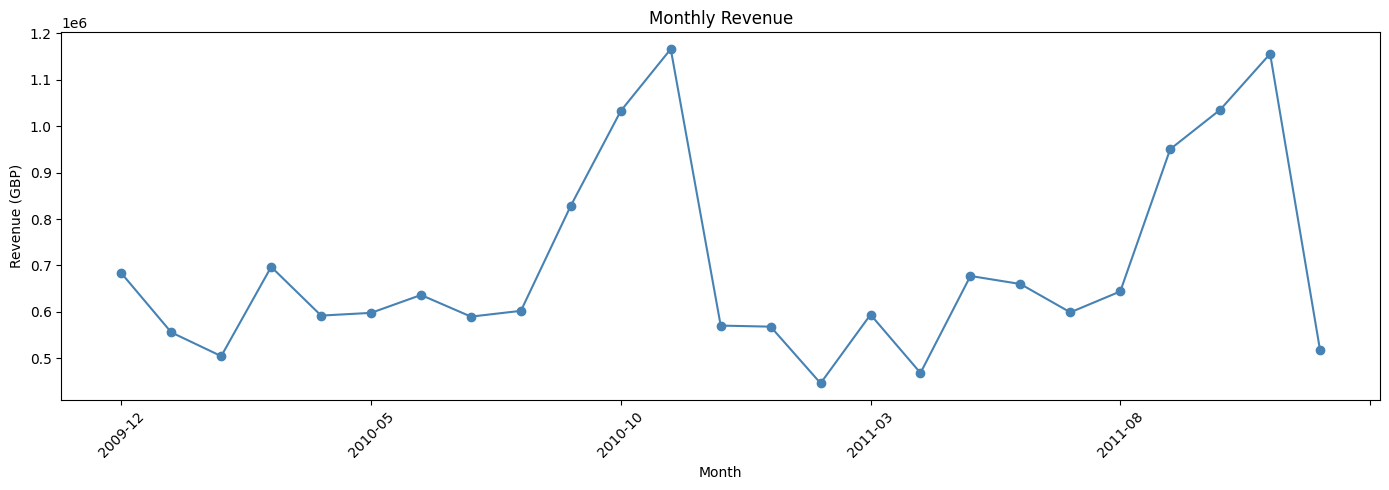

In [9]:
monthly = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

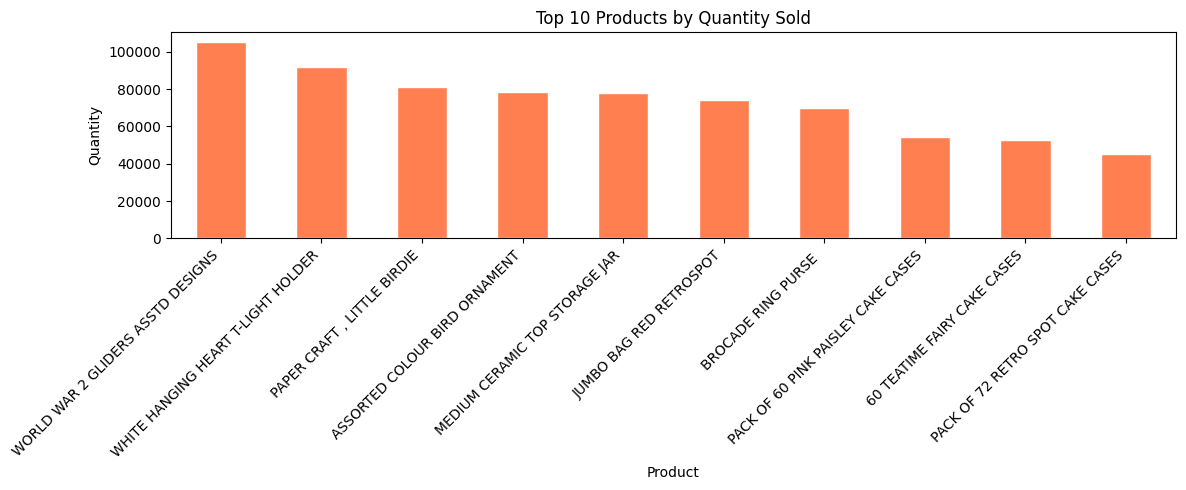

In [10]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_products.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

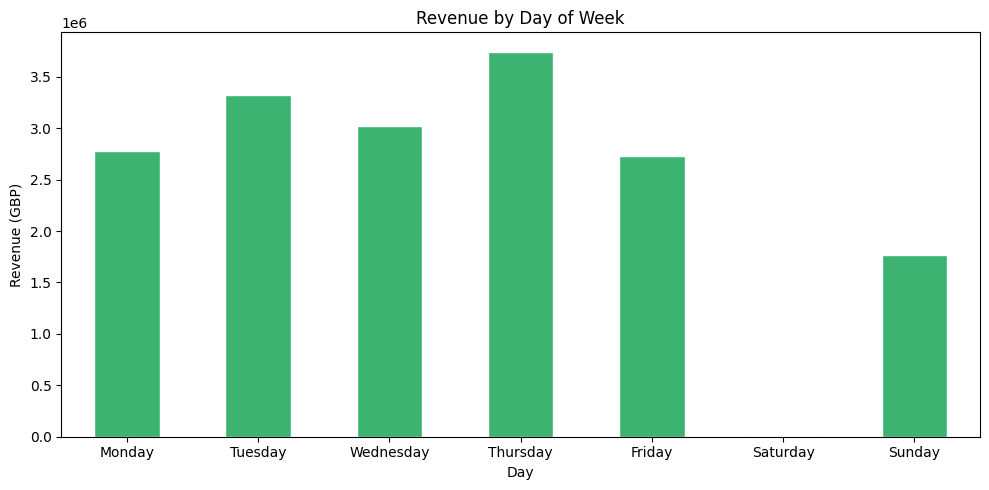

In [11]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales_day = df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
sales_day.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

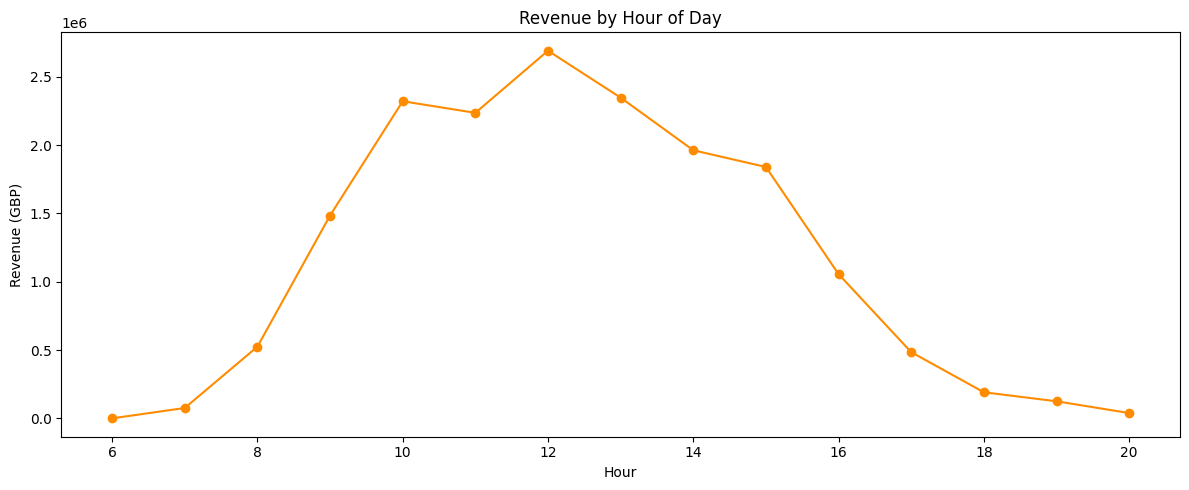

In [12]:
sales_hour = df.groupby('Hour')['TotalAmount'].sum()

plt.figure(figsize=(12, 5))
sales_hour.plot(kind='line', marker='o', color='darkorange')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue (GBP)')
plt.tight_layout()
plt.show()

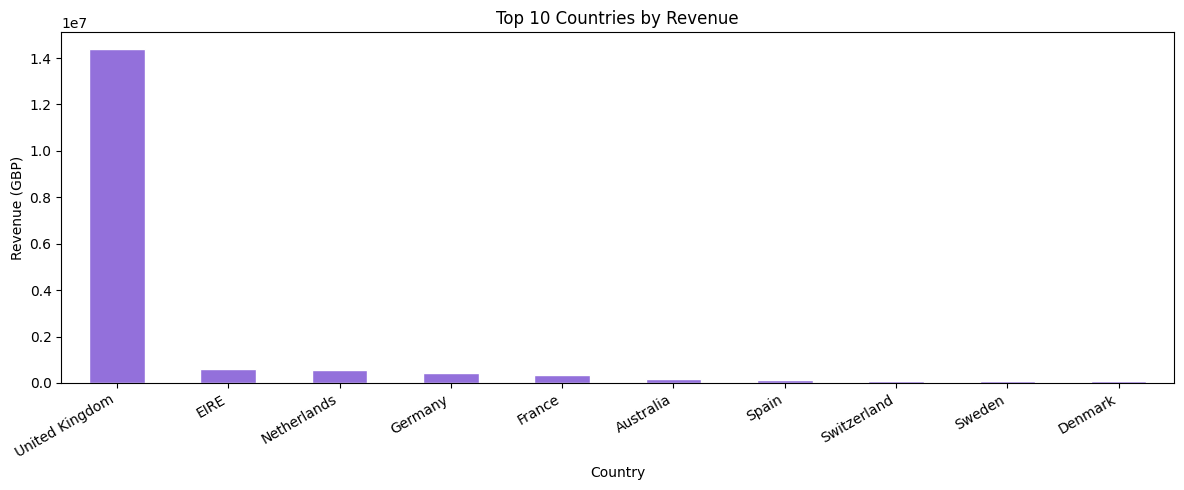

In [13]:
top_countries = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [14]:
df.to_csv('Data/cleaned_retail.csv', index=False)
print('Saved! Shape:', df.shape)

Saved! Shape: (779425, 12)
